In [6]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import os

random.seed(1337)

### Define Survival Analysis Functions

def discrete_survival_probabilities(hazards, max_t):
    """
    Calculate PMF and CDF from discrete-time hazards.
    
    Parameters:
    -----------
    hazards : array of π(t) for t = 1, 2, ..., max_t
    max_t   : maximum time period
    
    Returns:
    --------
    pmf : Pr(T = t) for each t
    cdf : Pr(T ≤ t) for each t  
    survival : Pr(T > t) for each t
    """
    
    pmf = np.zeros(max_t)
    cdf = np.zeros(max_t)
    survival = np.zeros(max_t)
    
    # Initialize
    survival_to_t = 1.0  # S(0) = 1, everyone "survives" to start
    cumulative_prob = 0.0
    
    for t in range(max_t):
        # PMF: probability of failure exactly at t
        # Pr(T = t) = π(t) × Pr(T ≥ t) = π(t) × S(t-1)
        pmf[t] = hazards[t] * survival_to_t
        
        # Update cumulative probability (CDF)
        cumulative_prob = cumulative_prob + pmf[t]
        cdf[t] = cumulative_prob
        
        # Update survival: S(t) = S(t-1) × (1 - π(t))
        survival_to_t = survival_to_t * (1 - hazards[t])
        survival[t] = survival_to_t
    
    return pmf, cdf, survival


# Alternative: Direct calculation without loop
def survival_function(hazards, t):
    """S(t) = ∏_{j=1}^{t} (1 - π(j))"""
    return np.prod(1 - hazards[:t])

def cdf_direct(hazards, t):
    """F(t) = 1 - S(t)"""
    return 1 - survival_function(hazards, t)

In [7]:
### Import Data and Train Model

boushey_2016_full = pd.read_stata(r"data/boushey2016.dta")

# Covariates
covariates = ["policycongruent","gub_election","elect2", "hvd_4yr", "fedcrime",
                "leg_dem_per_2pty","dem_governor","insession","propneighpol",
                "citidist","squire_prof86","citi6008","crimespendpc","crimespendpcsq",
                "violentthousand","pctwhite","stateincpercap","logpop","counter","counter2","counter3"]
boushey_2016 = boushey_2016_full[["state", "year", "billname", "dvadopt"] + covariates].dropna()

# Define X and y
X = boushey_2016[covariates].copy()
y = boushey_2016['dvadopt'].copy()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 1337, stratify = y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use best hyperparameters from the random-split experiment
rf_model = RandomForestClassifier(
    bootstrap = True,
    ccp_alpha = 0.0,
    class_weight = None,
    criterion = 'gini',
    max_depth = 10,
    min_samples_leaf = 3,
    n_estimators = 500,
    random_state = 1337
)

# Fit rf model
rf_model.fit(X_train_scaled, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


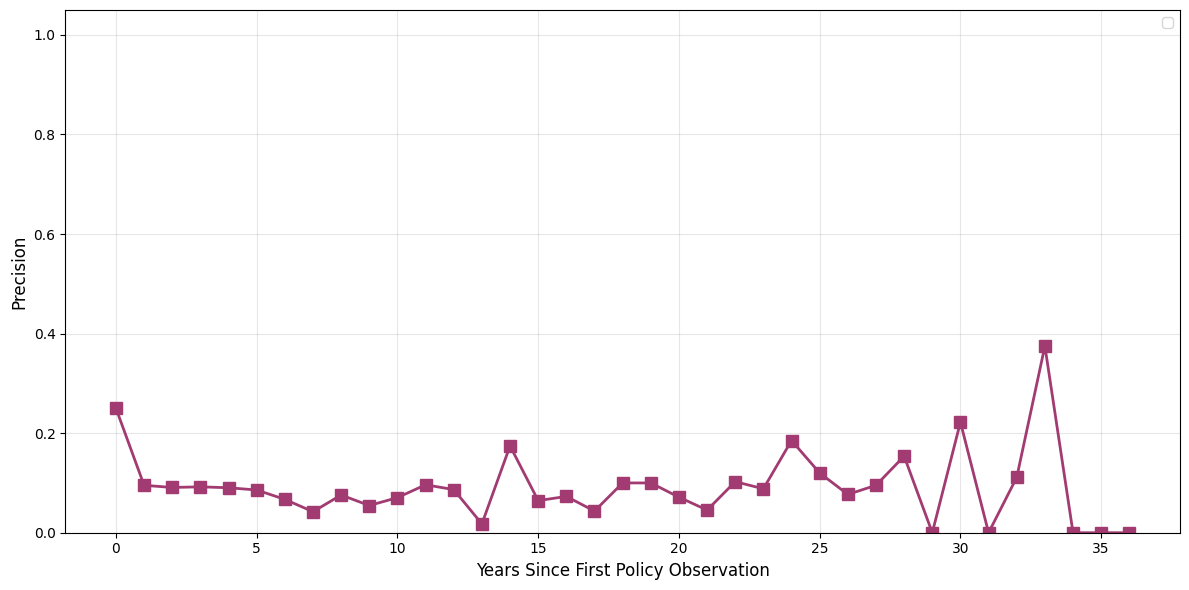

In [ ]:
# Get probability predictions (hazard rates) for survival analysis
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Get the corresponding metadata for test set
test_indices = y_test.index
test_metadata = boushey_2016_full.loc[test_indices, ['state', 'year', 'billname', 'dvadopt']].copy()
test_metadata['hazard_pred'] = y_pred_proba
test_metadata['actual'] = y_test.values

# For each policy, construct hazard sequence and calculate survival probabilities
policy_survival_analysis = []

for billname in test_metadata['billname'].unique():
    policy_data = test_metadata[test_metadata['billname'] == billname].sort_values('year')
    
    # Get hazard predictions over time
    hazards = policy_data['hazard_pred'].values
    max_t = len(hazards)
    
    # Calculate survival probabilities
    pmf, cdf, survival = discrete_survival_probabilities(hazards, max_t)
    
    # Store results
    for t, (year, actual) in enumerate(zip(policy_data['year'].values, policy_data['actual'].values)):
        policy_survival_analysis.append({
            'billname': billname,
            'year': year,
            'years_since_start': t,
            'hazard': hazards[t],
            'survival_prob': survival[t],
            'cumulative_adoption_prob': cdf[t],
            'actual_adopted': actual
        })

survival_df = pd.DataFrame(policy_survival_analysis)

# For each policy, calculate years since first observation to evaluate precision over time
survival_df['years_since_start'] = survival_df['year'] - survival_df.groupby('billname')['year'].transform('min')

# Now evaluate precision with cumulative adoption probability as prediction and actual adoption as ground truth
threshold = 0.5
survival_df['predicted_adopted_by_t'] = (survival_df['cumulative_adoption_prob'] >= threshold).astype(int)

# Calculate precision by years since start
survival_precision_results = []

for year in sorted(survival_df['years_since_start'].unique()):
    year_data = survival_df[survival_df['years_since_start'] == year]
    
    if len(year_data) > 0 and year_data['predicted_adopted_by_t'].sum() > 0:
        precision = precision_score(year_data['actual_adopted'], 
                                   year_data['predicted_adopted_by_t'], 
                                   zero_division=0)
        
        survival_precision_results.append({
            'years_since_start': year,
            'precision': precision,
            'n_samples': len(year_data)
        })

survival_precision_df = pd.DataFrame(survival_precision_results)

# Plot precision from survival model
plt.figure(figsize=(12, 6))
plt.plot(survival_precision_df['years_since_start'], survival_precision_df['precision'], 
         marker='s', linewidth=2, markersize=8, color='#A23B72')
plt.xlabel('Years Since First Policy Observation', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()